
Project 2: Fake Job Posting Detection
---------------------------------------

Author: Riya Vadadoria

In this project, I explore how data science and natural language processing (NLP) 
can help detect fraudulent job postings. The goal is to understand the characteristics 
that make some job listings fake — and how we can use data to spot them automatically.

The dataset (`fake_job_postings.csv`) includes thousands of job listings, both genuine 
and fraudulent, with information such as job title, company profile, description, 
requirements, benefits, and telecommuting options.

Here's what this notebook does:
1. **Data Cleaning & Preparation**
   - Cleans messy text (removes HTML, URLs, and special characters).
   - Handles missing values and creates new features like missing company profile or location frequency.
   - Combines multiple text columns into a single, clean text field for modeling.

2. **Feature Engineering**
   - Uses TF-IDF vectorization to convert text into numerical features.
   - Scales numeric data (e.g., telecommuting, profile presence) for model compatibility.

3. **Exploratory Data Analysis (EDA)**
   - Visualizes class balance between real and fake job posts.
   - Studies how factors like telecommuting or missing profiles relate to fraud.
   - Looks at description length differences and most frequent n-grams in both classes.

4. **Insights**
   - By the end, you’ll see patterns that make fake jobs stand out, such as vague descriptions, 
     missing profiles, or overuse of certain phrases.
   - These findings can later guide machine learning models to detect fraudulent job posts more accurately.

This project blends text analytics and visualization to uncover hidden trends 
in online job scams — showing how data can help make job searching safer.


In [21]:
import re
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler

In [11]:
def clean_text(s: str) -> str:
    """Basic text cleaning: lowercase, remove URLs, HTML, and non-letters."""
    if not isinstance(s, str):
        s = "" if pd.isna(s) else str(s)
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)        # remove URLs
    s = re.sub(r"<[^>]+>", " ", s)                 # remove HTML
    s = re.sub(r"[^a-z\s']", " ", s)               # keep only letters/apostrophes
    s = re.sub(r"\s+", " ", s).strip()             # collapse spaces
    return s

In [12]:
# ---- 1) Load dataset ----
CSV_PATH = "fake_job_postings.csv"  
df = pd.read_csv(CSV_PATH)
df

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


In [13]:
# ---- 2) Define columns ----
TEXT_COLS = ["title", "company_profile", "description", "requirements", "benefits"]
META_COLS = ["location", "telecommuting"]
TARGET_COL = "fraudulent"

keep_cols = [c for c in (TEXT_COLS + META_COLS + [TARGET_COL]) if c in df.columns]
df = df[keep_cols].copy()

In [14]:
# ---- 3) Handle missing ----
for c in TEXT_COLS:
    if c in df.columns:
        df[c] = df[c].fillna("").astype(str).map(clean_text)

if "location" in df.columns:
    df["location"] = df["location"].fillna("Unknown").astype(str)

if "telecommuting" in df.columns:
    df["telecommuting"] = df["telecommuting"].fillna(0).astype(int)
else:
    df["telecommuting"] = 0

In [15]:
# ---- 4) Derived features ----
df["missing_company_profile"] = (df.get("company_profile", "").str.strip() == "").astype(int)

df["text_all"] = (
    df.get("title", "") + " " +
    df.get("company_profile", "") + " " +
    df.get("description", "") + " " +
    df.get("requirements", "") + " " +
    df.get("benefits", "")
).str.strip()

loc_counts = df["location"].value_counts(dropna=False)
df["location_freq"] = df["location"].map(loc_counts).astype(float)

In [16]:
# ---- 5) Features + target ----
NUMERIC_FEATURES = ["telecommuting", "missing_company_profile", "location_freq"]
X = df[["text_all"] + NUMERIC_FEATURES].copy()
y = df[TARGET_COL].astype(int).values

In [17]:
# ---- 6) Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [18]:
# ---- 7) TF-IDF + scaling ----
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_features=50_000
)
X_train_text = vectorizer.fit_transform(X_train["text_all"])
X_test_text  = vectorizer.transform(X_test["text_all"])

scaler = MaxAbsScaler()
X_train_num = scaler.fit_transform(X_train[NUMERIC_FEATURES].astype(float).values)
X_test_num  = scaler.transform(X_test[NUMERIC_FEATURES].astype(float).values)

In [19]:
# ---- 8) Stack into sparse matrices ----
X_train_proc = sparse.hstack([X_train_text, X_train_num], format="csr")
X_test_proc  = sparse.hstack([X_test_text,  X_test_num],  format="csr")

print("X_train_proc:", X_train_proc.shape, "| X_test_proc:", X_test_proc.shape)
print("y_train counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test counts :", dict(zip(*np.unique(y_test,  return_counts=True))))


X_train_proc: (14304, 50003) | X_test_proc: (3576, 50003)
y_train counts: {0: 13611, 1: 693}
y_test counts : {0: 3403, 1: 173}


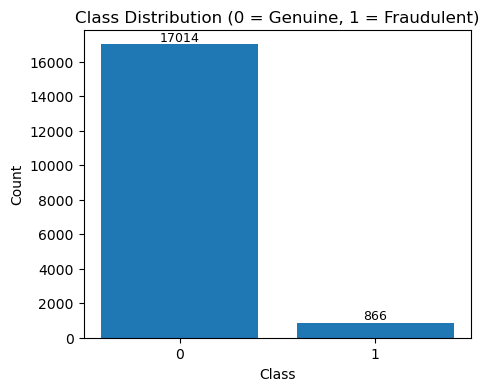

Class counts: {0: 17014, 1: 866}
Fraud rate: 4.84%


In [22]:
# =========================
# 1) Class Distribution
# =========================
cls_counts = df[TARGET_COL].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(cls_counts.index.astype(str), cls_counts.values)
plt.title("Class Distribution (0 = Genuine, 1 = Fraudulent)")
plt.xlabel("Class")
plt.ylabel("Count")
for i, v in enumerate(cls_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.show()

print("Class counts:", cls_counts.to_dict())
print("Fraud rate: {:.2f}%".format(100.0 * cls_counts.get(1,0) / max(1, cls_counts.sum())))

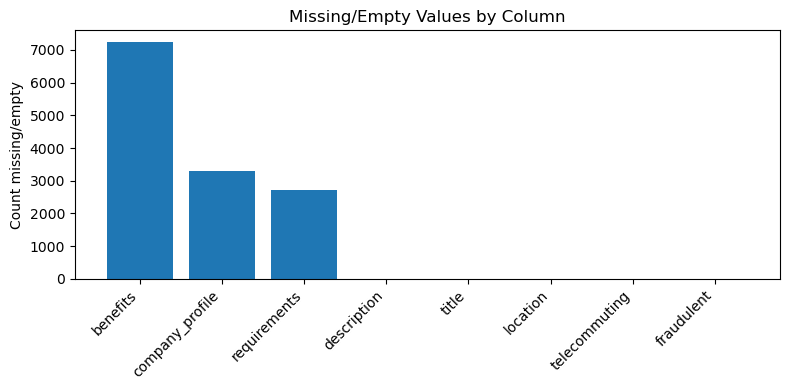

In [23]:
# =========================
# 2) Missing/Empty by Column (subset of common cols)
# =========================
cols_for_missing = [c for c in (TEXT_COLS + ["location","telecommuting",TARGET_COL]) if c in df.columns]
missing_counts = df[cols_for_missing].isna().sum() + (df[cols_for_missing] == "").sum()
missing_counts = missing_counts.sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(missing_counts.index, missing_counts.values)
plt.title("Missing/Empty Values by Column")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count missing/empty")
plt.tight_layout()
plt.show()

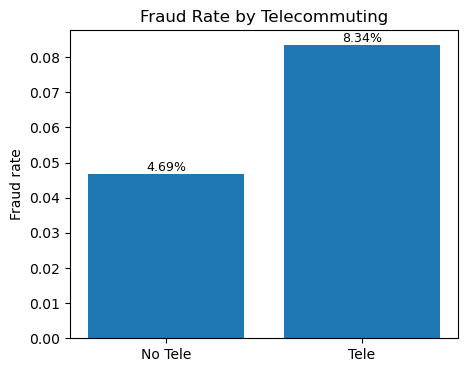

Fraud rate by telecommuting: {0: 0.04686495646584468, 1: 0.08344198174706649}


In [27]:
# =========================
# 3) Fraud rate vs Telecommuting
# =========================
tele_pivot = df.groupby("telecommuting")[TARGET_COL].mean()
plt.figure(figsize=(5,4))
plt.bar(["No Tele", "Tele"], [tele_pivot.get(0,0), tele_pivot.get(1,0)])
plt.title("Fraud Rate by Telecommuting")
plt.ylabel("Fraud rate")
for i, v in enumerate([tele_pivot.get(0,0), tele_pivot.get(1,0)]):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom', fontsize=9)
plt.show()
print(
    "Fraud rate by telecommuting:",
    {int(k): float(v) for k, v in tele_pivot.to_dict().items()}
)


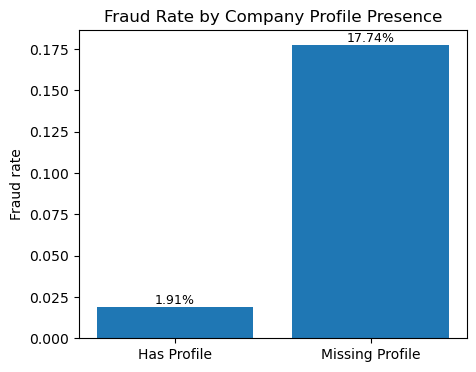

Fraud rate by missing_company_profile: {0: 0.01914630798792204, 1: 0.17744860943168078}


In [28]:
# =========================
# 4) Fraud rate vs Missing Company Profile
# =========================
mcp = df.groupby("missing_company_profile")[TARGET_COL].mean()
plt.figure(figsize=(5,4))
plt.bar(["Has Profile","Missing Profile"], [mcp.get(0,0), mcp.get(1,0)])
plt.title("Fraud Rate by Company Profile Presence")
plt.ylabel("Fraud rate")
for i, v in enumerate([mcp.get(0,0), mcp.get(1,0)]):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom', fontsize=9)
plt.show()
print("Fraud rate by missing_company_profile:", {int(k): float(v) for k,v in mcp.to_dict().items()})



posx and posy should be finite values
posx and posy should be finite values


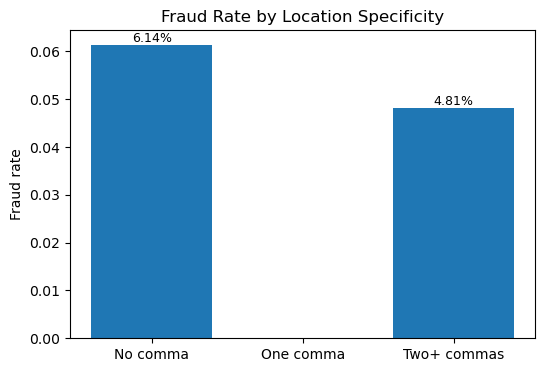

Fraud rate by location specificity: {'No comma': 0.06136363636363636, 'One comma': nan, 'Two+ commas': 0.048110556797981534}


In [29]:
# =========================
# 5) Location Specificity Proxy (comma count)
# =========================
loc_spec = df["location"].astype(str).map(lambda s: s.count(","))
bins = pd.cut(loc_spec, bins=[-0.5,0.5,1.5,10], labels=["No comma","One comma","Two+ commas"])
spec_rate = df.groupby(bins)[TARGET_COL].mean()

plt.figure(figsize=(6,4))
plt.bar(spec_rate.index.astype(str), spec_rate.values)
plt.title("Fraud Rate by Location Specificity")
plt.ylabel("Fraud rate")
for i, v in enumerate(spec_rate.values):
    plt.text(i, v, f"{v:.2%}", ha='center', va='bottom', fontsize=9)
plt.show()
print("Fraud rate by location specificity:", {str(k): float(v) for k,v in spec_rate.to_dict().items()})

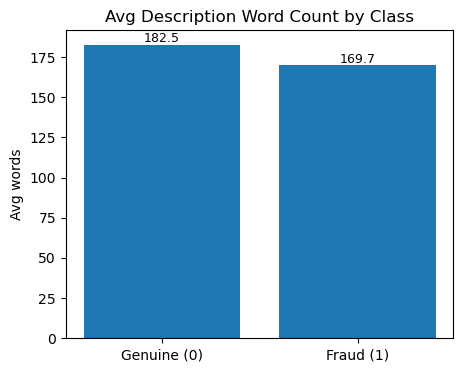

Average description length: {0: 182.47478547078876, 1: 169.70554272517322}


In [32]:
# =========================
# 6) Avg Description Length by Class  (safe version)
# =========================

if "description_len" not in df.columns:
    if "description" not in df.columns:
        df["description"] = ""
    df["description_len"] = (
        df["description"].astype(str).map(clean_text).map(lambda s: len(s.split()))
    )

desc_len_stats = df.groupby(TARGET_COL)["description_len"].mean()

plt.figure(figsize=(5,4))
plt.bar(
    ["Genuine (0)", "Fraud (1)"],
    [desc_len_stats.get(0, 0.0), desc_len_stats.get(1, 0.0)]
)
plt.title("Avg Description Word Count by Class")
plt.ylabel("Avg words")
for i, v in enumerate([desc_len_stats.get(0, 0.0), desc_len_stats.get(1, 0.0)]):
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom', fontsize=9)
plt.show()

print("Average description length:", {int(k): float(v) for k, v in desc_len_stats.to_dict().items()})


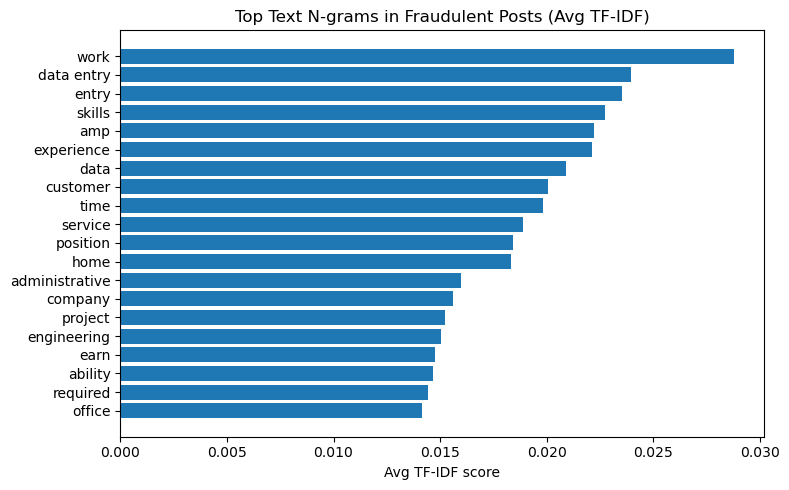

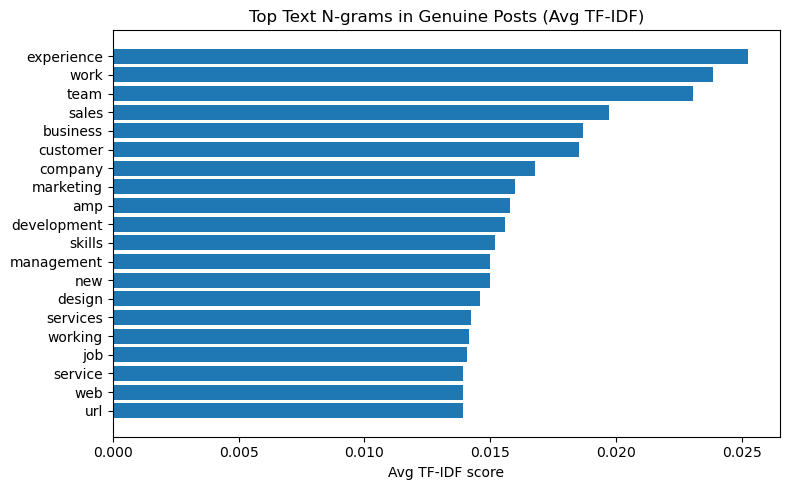

Top tokens (fraud): [('work', 0.028773848692227235), ('data entry', 0.023950949880033517), ('entry', 0.02351965048738526), ('skills', 0.022724416187314186), ('amp', 0.022205894582676737), ('experience', 0.022116820247441334), ('data', 0.02091733564443998), ('customer', 0.020064642959863595), ('time', 0.01981979891700559), ('service', 0.018865445575190425)]
Top tokens (genuine): [('experience', 0.025251144665594485), ('work', 0.02383761869733028), ('team', 0.023049377374320622), ('sales', 0.019720178796670113), ('business', 0.01870079846501089), ('customer', 0.018540960656218162), ('company', 0.016770337414435375), ('marketing', 0.01597655238853697), ('amp', 0.01580268596064508), ('development', 0.01557240750363459)]


In [33]:
# =========================
# 7) Top N-grams per Class (reuse your vectorizer if present; else a temp one)
# =========================
# Prefer your existing `vectorizer` from preprocessing if available
if 'vectorizer' in globals() and isinstance(vectorizer, TfidfVectorizer):
    vec = vectorizer
    X_all = vec.transform(df["text_all"])
else:
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=10, max_features=30000)
    X_all = vec.fit_transform(df["text_all"])

vocab = np.array(vec.get_feature_names_out())
fraud_mask = (df[TARGET_COL] == 1).values
real_mask  = (df[TARGET_COL] == 0).values

def _top_terms(mask, top_k=20):
    if mask.sum() == 0:
        return []
    X_sub = X_all[mask]
    avg = np.asarray(X_sub.mean(axis=0)).ravel()
    top_idx = np.argsort(-avg)[:top_k]
    return list(zip(vocab[top_idx], avg[top_idx]))

top_fraud = _top_terms(fraud_mask, 20)
top_real  = _top_terms(real_mask, 20)

def _plot_top_terms(pairs, title):
    if not pairs:
        print(f"No terms to plot for: {title}")
        return
    terms, scores = zip(*pairs)
    y = np.arange(len(terms))[::-1]
    plt.figure(figsize=(8,5))
    plt.barh(y, scores)
    plt.yticks(y, terms)
    plt.title(title)
    plt.xlabel("Avg TF-IDF score")
    plt.tight_layout()
    plt.show()

_plot_top_terms(top_fraud, "Top Text N-grams in Fraudulent Posts (Avg TF-IDF)")
_plot_top_terms(top_real,  "Top Text N-grams in Genuine Posts (Avg TF-IDF)")

print("Top tokens (fraud):", top_fraud[:10])
print("Top tokens (genuine):", top_real[:10])